# Task 1: Exploratory Data Analysis (EDA) on the Iris Dataset

**Objective:** Explore and understand the Iris dataset using industry-standard EDA techniques — inspecting the data, checking data quality, and visualizing relationships between features to draw insights.

---

## 1. Import Libraries

In [1]:
# Import the libraries we need for data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make our charts colorful and consistent
sns.set_style("whitegrid")
sns.set_palette("husl")
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load the Dataset

We are using the classic **Iris dataset**, which contains 150 samples of iris flowers from 3 species
(*setosa*, *versicolor*, *virginica*), with 4 measured features: sepal length, sepal width,
petal length, and petal width (all in cm).

In [2]:
# Load the dataset from the local CSV file
df = pd.read_csv("data/iris.csv")

# Display the first 5 rows
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 3. Basic Data Inspection

In [3]:
# Shape of the dataset (rows, columns)
print("Shape of dataset:", df.shape)

Shape of dataset: (150, 5)


In [4]:
# Column names and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [5]:
# Check for missing values in each column
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [6]:
# Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 1


In [7]:
# Statistical summary of the numeric columns
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [8]:
# How many samples do we have per species?
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

### Observations
- The dataset has **150 rows and 5 columns** (4 numeric features + 1 categorical target).
- There are **no missing values** and **no duplicate rows**, the data is clean.
- The dataset is **perfectly balanced**: 50 samples for each of the 3 species.

## 4. Univariate Analysis, Distribution of Each Feature

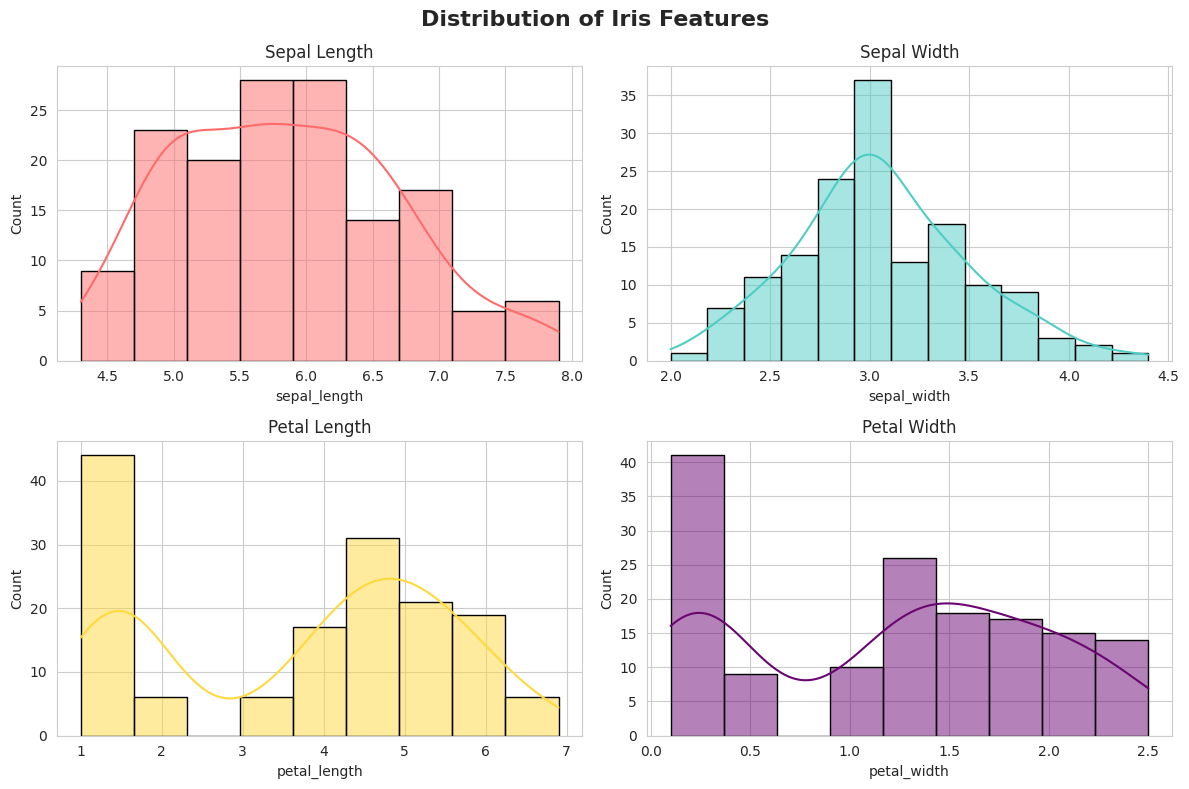

In [9]:
# Histograms for each numeric feature, colored nicely
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Distribution of Iris Features", fontsize=16, fontweight='bold')

colors = ['#FF6B6B', '#4ECDC4', '#FFD93D', '#6A0572']
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

for ax, feature, color in zip(axes.flatten(), features, colors):
    sns.histplot(df[feature], kde=True, color=color, ax=ax, edgecolor='black')
    ax.set_title(f'{feature.replace("_", " ").title()}')

plt.tight_layout()
plt.savefig("screenshots/01_feature_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_539/584952350.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=feature, data=df, ax=ax, palette='Set2')
/tmp/ipykernel_539/584952350.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=feature, data=df, ax=ax, palette='Set2')
/tmp/ipykernel_539/584952350.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=feature, data=df, ax=ax, palette='Set2')
/tmp/ipykernel_539/584952350.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14

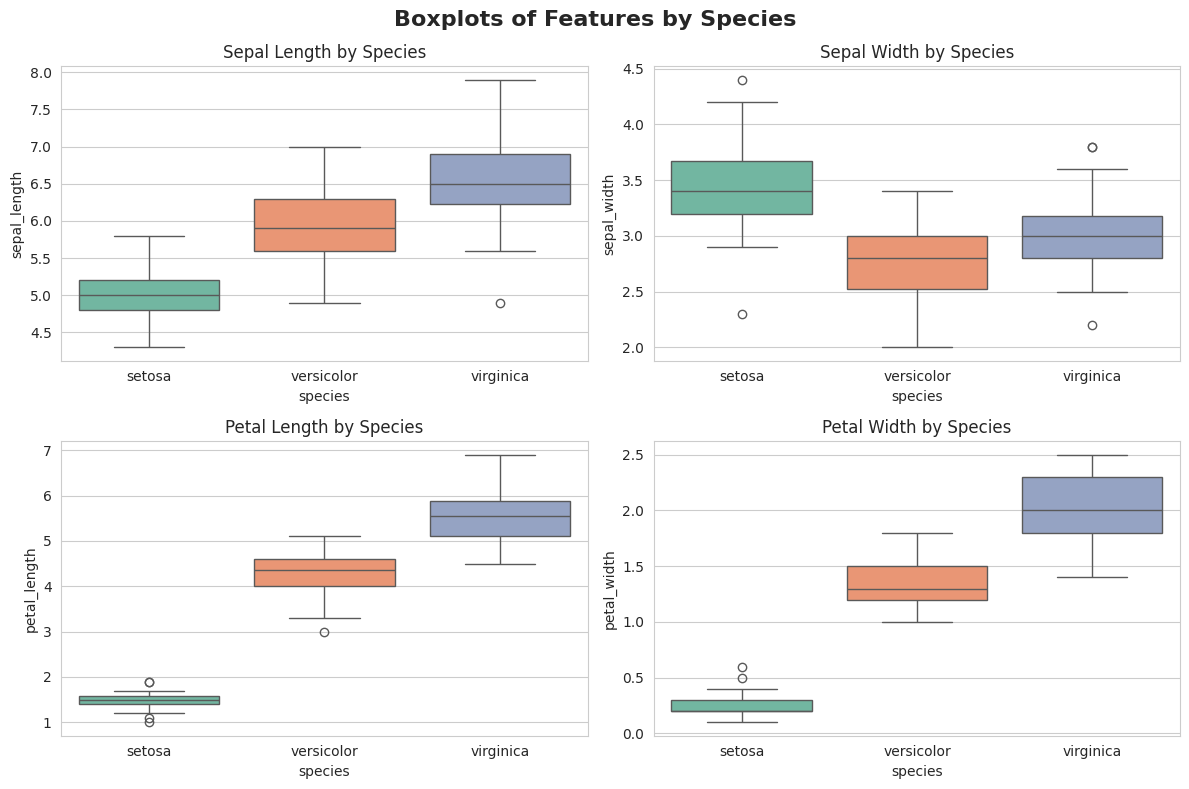

In [10]:
# Boxplots to see the spread and outliers of each feature by species
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Boxplots of Features by Species", fontsize=16, fontweight='bold')

for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(x='species', y=feature, data=df, ax=ax, palette='Set2')
    ax.set_title(f'{feature.replace("_", " ").title()} by Species')

plt.tight_layout()
plt.savefig("screenshots/02_boxplots_by_species.png", dpi=150, bbox_inches='tight')
plt.show()

### Observation
Looking at the boxplots, **petal length** and **petal width** show the clearest separation
between species — *setosa* has noticeably smaller petals than *versicolor* and *virginica*.
This suggests petal measurements will be strong predictors for classifying species.

## 5. Bivariate Analysis, Relationships Between Features

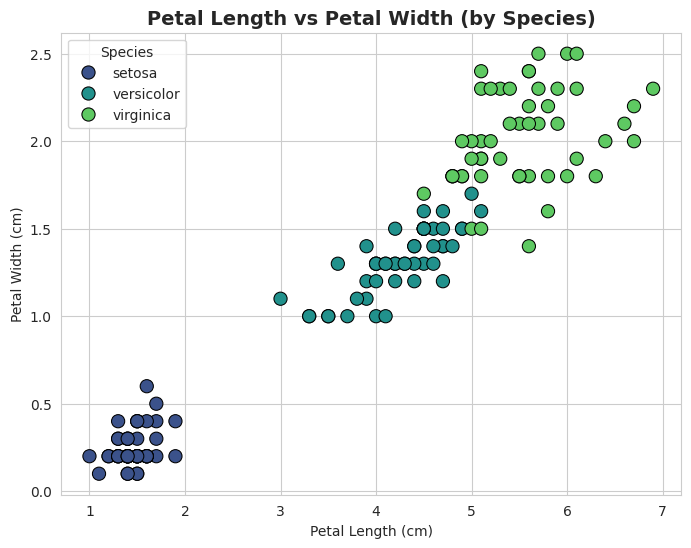

In [11]:
# Scatter plot: Petal Length vs Petal Width, colored by species
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species',
                 palette='viridis', s=90, edgecolor='black')
plt.title('Petal Length vs Petal Width (by Species)', fontsize=14, fontweight='bold')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Species')
plt.savefig("screenshots/03_petal_scatter.png", dpi=150, bbox_inches='tight')
plt.show()

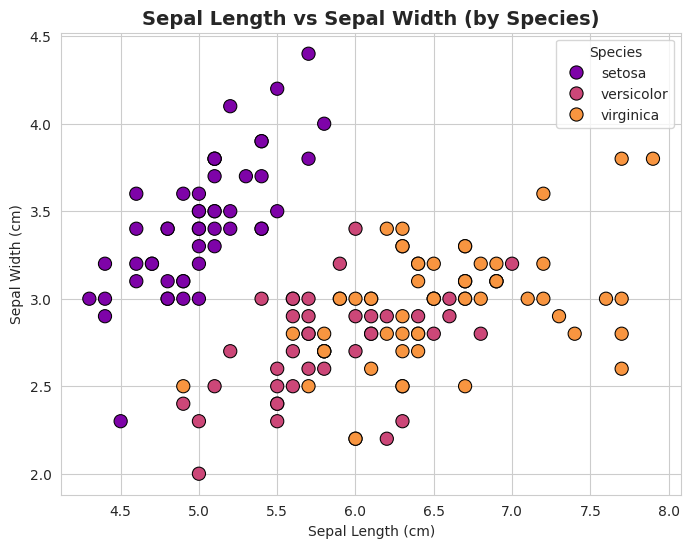

In [12]:
# Scatter plot: Sepal Length vs Sepal Width, colored by species
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='sepal_length', y='sepal_width', hue='species',
                 palette='plasma', s=90, edgecolor='black')
plt.title('Sepal Length vs Sepal Width (by Species)', fontsize=14, fontweight='bold')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend(title='Species')
plt.savefig("screenshots/04_sepal_scatter.png", dpi=150, bbox_inches='tight')
plt.show()

## 6. Pairplot, All Features at Once

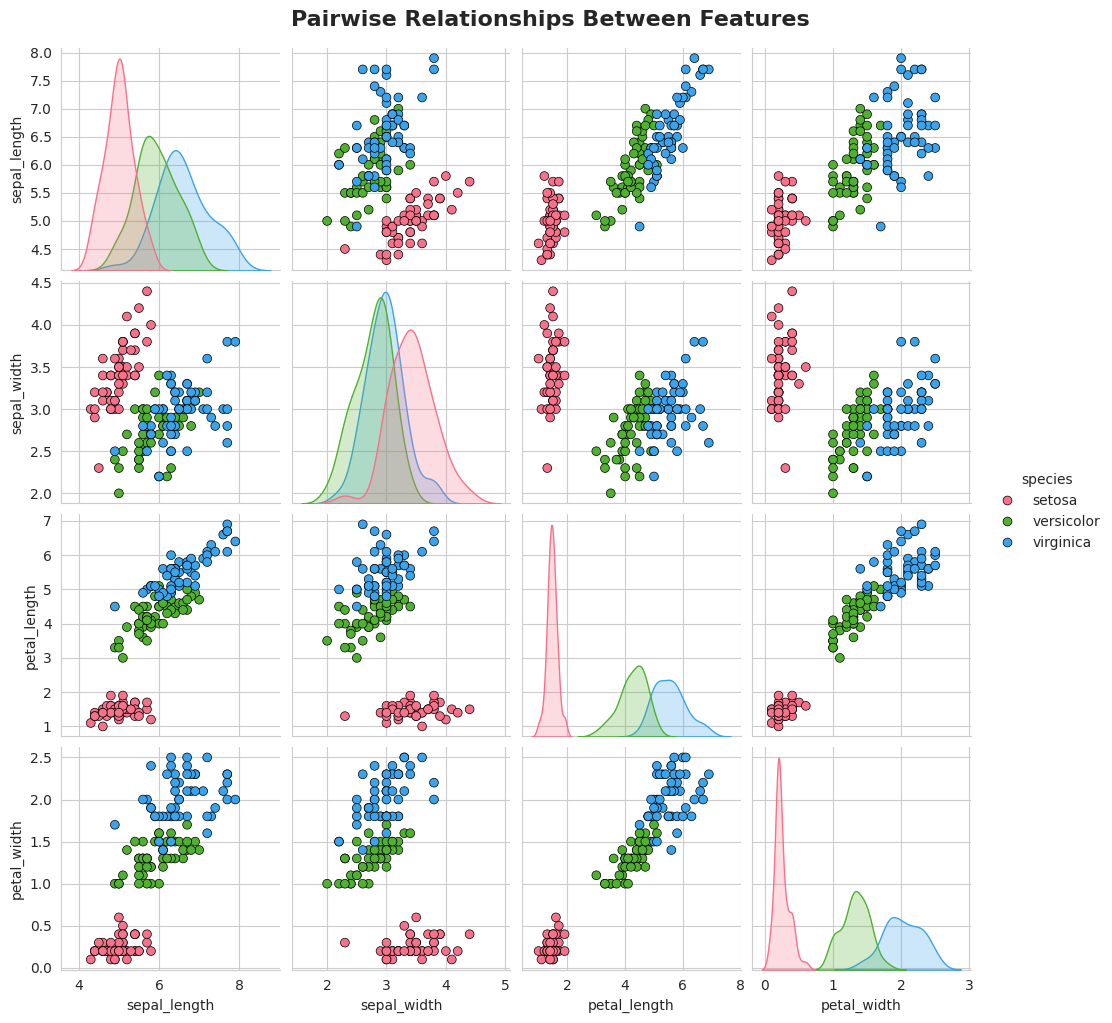

In [13]:
# Pairplot shows every feature plotted against every other feature
pairplot = sns.pairplot(df, hue='species', palette='husl', diag_kind='kde',
                         plot_kws={'edgecolor': 'black', 's': 40})
pairplot.fig.suptitle('Pairwise Relationships Between Features', y=1.02, fontsize=16, fontweight='bold')
pairplot.savefig("screenshots/05_pairplot.png", dpi=150, bbox_inches='tight')
plt.show()

## 7. Correlation Heatmap

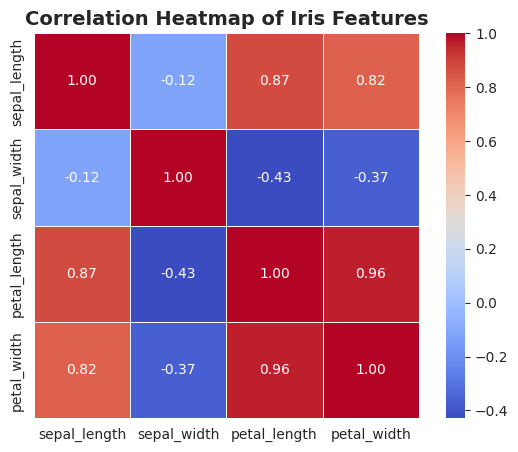

In [14]:
# Correlation matrix between the numeric features
plt.figure(figsize=(7, 5))
corr = df[features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, square=True)
plt.title('Correlation Heatmap of Iris Features', fontsize=14, fontweight='bold')
plt.savefig("screenshots/06_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

### Observation
- **Petal length and petal width are very strongly correlated (≈0.96)** , as one increases, so does the other.
- **Sepal width has a weak/negative correlation** with the other features.
- Petal measurements correlate strongly with sepal length too, showing they carry a lot of the
  "size" information in the flower.

## 8. Species Count Visualization

/tmp/ipykernel_539/1209641029.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='species', data=df, palette='cool', edgecolor='black')


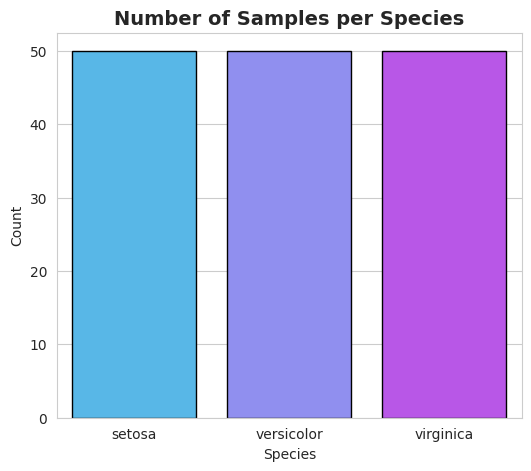

In [15]:
# Simple, colorful bar chart of species counts
plt.figure(figsize=(6, 5))
sns.countplot(x='species', data=df, palette='cool', edgecolor='black')
plt.title('Number of Samples per Species', fontsize=14, fontweight='bold')
plt.xlabel('Species')
plt.ylabel('Count')
plt.savefig("screenshots/07_species_count.png", dpi=150, bbox_inches='tight')
plt.show()